### Create SMET Forcing Files

Notebook contents 
* SNOWPACK takes an SMET file, so let's create that for point simulations

created by Cassie Lumbrazo\
last updated: Feb 2025\
run location: UAS linux\
python environment: **xarray** Now, change to **rasterio** to load the netcdf with crs etc.

In [63]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

In [64]:
import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd

In [65]:
from zoneinfo import ZoneInfo
from pathlib import Path

In [66]:
pwd

'/home/cassie/python/repos/snow_model_forcing'

So actually this python library exists: PySMET: https://snowpat.slf.ch/indexsmet/

but I am going to create my own script for now... 

## Load the HRRR Dataset, 
that we created in `2_clean_hrrrak_netcdf.ipynb`, a test for WY2024 for now

In [67]:
input_file = '/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2024_test1_utm_pp.nc'
ds = xr.open_dataset(input_file)

# write the crs 
ds.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work
ds

<xarray.Dataset> Size: 781kB
Dimensions:                  (time: 3311)
Coordinates:
  * time                     (time) datetime64[ns] 26kB 2023-10-01T05:00:00 ....
    valid_time               (time) datetime64[ns] 26kB ...
    step                     (time) timedelta64[ns] 26kB ...
    x                        float64 8B ...
    y                        float64 8B ...
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Data variables: (12/53)
    pt                       (time) float32 13kB ...
    temp                     (time) float32 13kB ...
    d2m                      (time) float32 13kB ...
    sh2                      (time) float32 13kB ...
    rh                       (time) float32 13kB ...
    u10                      (time) float32 13kB ...
    ...                       ...
    vgtyp                    (time) float32 13kB ...
    cloud_total              (time) float32 13kB ...
    cloud_high               (time) float32 13kB ...
    cloud_low                (time) float32 13kB ...
    wind                     (time) float32 13kB ...
    temp_c                   (time) float32 13kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

In [68]:
# check the crs 
print(ds.rio.crs)

EPSG:32608


In [69]:
# cut the dataset to be just a few days in January for testing
# ds = ds.sel(time=slice('2023-12-15T00:00:00', '2024-01-05T00:00:00'))
# ds

# The Workflow Below, 

HRRR (NetCDF / xarray)\
   → your Python script\
   → SMET (ASCII)\
   → SNOWPACK


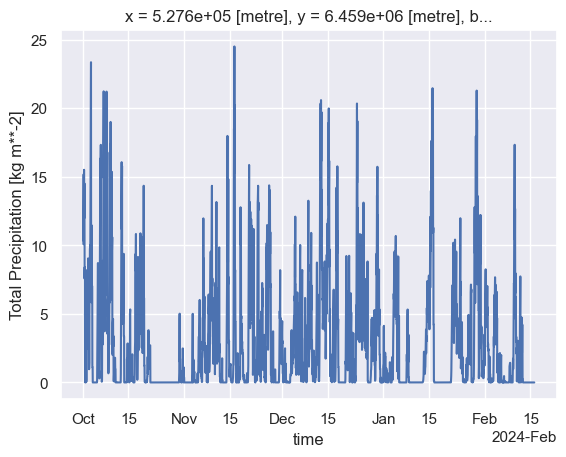

In [70]:
# ds.t2m # I think it was this, but I changed it to "temp" in the previous script

# ds.temp.plot() # 2-m surface temperature in K, need in K
# ds.rh.plot() # 2-m relative humidity in %, need in fraction (0-1)
# ds.u10.plot() # 10-m u wind component in m/s, need in m/s
# ds.v10.plot() # 10-m v wind component in m/s, need in m/s
# ds.swrad.plot() # surface downward shortwave radiation in W/m2, need in W/m2
# ds.lwrad.plot() # surface downward longwave radiation in W/m2, need in W/m2
ds.tp.plot() # total precipitation in kg/m2, need in mm per timestep, actually in precipitional (incredment) 
# ds.precip_rate.plot() # precipitation rate in kg/m2s, need in mm per timestep
# ds.sp.plot() # surface pressure in Pa, need in Pa

In [71]:
ds.tp.attrs

{'GRIB_paramId': np.int32(228228),
 'GRIB_dataType': 'fc',
 'GRIB_numberOfPoints': np.int32(420),
 'GRIB_typeOfLevel': 'surface',
 'GRIB_stepUnits': np.int32(1),
 'GRIB_stepType': 'accum',
 'GRIB_gridType': 'polar_stereographic',
 'GRIB_NV': np.int32(0),
 'GRIB_cfName': 'unknown',
 'GRIB_cfVarName': 'tp',
 'GRIB_gridDefinitionDescription': 'Polar stereographic can be south or north',
 'GRIB_missingValue': np.float64(3.4028234663852886e+38),
 'GRIB_name': 'Total Precipitation',
 'GRIB_shortName': 'tp',
 'GRIB_units': 'kg m**-2',
 'long_name': 'Total Precipitation',
 'units': 'kg m**-2',
 'standard_name': 'unknown',
 'grid_mapping': 'spatial_ref'}

#### MeteoIO Variable Names 
| MeteoIO name | Meaning                      | Required?            | Expected units              |
| ------------ | ---------------------------- | -------------------- | --------------------------- |
| `TA`         | Air temperature              | yes                  | °K                          |
| `RH`         | Relative humidity            | yes                  | fraction (0-1)              |
| `VW`         | Wind speed                   | yes                  | m s⁻¹                       |
| `DW`         | Wind direction               | optional             | degrees (0–360, from North) |
| `ISWR`       | Incoming shortwave radiation | strongly recommended | W m⁻²                       |
| `ILWR`       | Incoming longwave radiation  | strongly recommended | W m⁻²                       |
| `PSUM`       | Precipitation (increment)    | yes                  | mm (per timestep)           |
| `P`          | Air pressure                 | optional             | Pa                          |


HRRR to MeteIO Variable Mapping 

In [72]:
# --- Unit expectations (SMET / MeteoIO) ---
# TA    : Kelvin
# RH    : fraction (0–1)
# VW    : m s-1
# DW    : degrees (meteorological)
# ISWR : W m-2
# ILWR : W m-2
# PSUM : mm per timestep
# P     : Pa

# Create SMET File

In [73]:
    # filename="\home\cassie\python\run_snowpack\test\input\hrrr_point_test.smet", # location for now 
    # station_id="HRRR_POINT", # leaving this for now to match the config files... 
    # latitude=58.26200,
    # longitude=-134.51700,
    # altitude=670, # meters above sea level

In [75]:
from pyproj import Transformer

In [ ]:
# =========================
# USER SETTINGS
# =========================
# OUTFILE = Path("HRRR_point.smet")
OUTFILE = Path("/home/cassie/python/run_snowpack/test1/input/HRRR_POINT.smet") # location of the test for now

STATION_ID = "HRRR_POINT"
STATION_NAME = "HRRR Powder Patch Point Forcing"
LAT = 58.262      # site latitude
LON = -134.517    # site longitude
ELEV = 670        # site elevation (m)
EPSG = 32608      # UTM zone for site
TZ = 0            # UTC
NODATA = -999

# =========================
# COORDINATE TRANSFORM
# WGS84 (lat/lon) → UTM Zone 8N
transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32608",
    always_xy=True
)

EASTING, NORTHING = transformer.transform(LON, LAT)


# =========================
# VARIABLE MAPPING
# =========================
VARMAP = {
    "TA": ds.temp,       # K
    "RH": ds.rh / 100.0, # % → fraction
    "U": ds.u10,         # m/s
    "V": ds.v10,         # m/s
    "ISWR": ds.swrad,    # W/m2
    "ILWR": ds.lwrad,    # W/m2
    "PSUM": ds.tp,       # kg/m2 = mm per timestep # need to fix precip
    "PS": ds.sp          # Pa
}

# =========================
# BUILD DATAFRAME
# =========================
time = pd.to_datetime(ds.time.values)

df = pd.DataFrame(index=time)

df["TA"] = VARMAP["TA"].values
df["RH"] = VARMAP["RH"].values
df["ISWR"] = VARMAP["ISWR"].values
df["ILWR"] = VARMAP["ILWR"].values
df["PS"] = VARMAP["PS"].values

# --- precipitation (HRRR total precip → incremental) ---
tp = ds.tp.load()

psum = tp.diff("time")
psum = psum.reindex(time=tp.time)
psum = psum.fillna(0.0)
psum = psum.where(psum >= 0.0, 0.0)

df["PSUM"] = psum.values


# ---- Wind speed & direction ----
u = VARMAP["U"].values
v = VARMAP["V"].values

df["VW"] = np.sqrt(u**2 + v**2)
df["DW"] = (270.0 - np.degrees(np.arctan2(v, u))) % 360.0

# Replace missing values
df = df.fillna(NODATA)

# =========================
# WRITE SMET
# =========================
with open(OUTFILE, "w") as f:
    f.write("SMET 1.1 ASCII\n")
    f.write("[HEADER]\n")

    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")

    # Geographic metadata (optional but useful)
    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")

    # Projected coordinates (authoritative)
    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")
    f.write(f"epsg             = {EPSG}\n")

    f.write(f"altitude         = {ELEV}\n")
    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")

    f.write("source           = HRRR point extraction\n")
    f.write("fields           = timestamp TA RH VW DW ISWR ILWR PSUM PS\n")
    f.write("[DATA]\n")


    for t, row in df.iterrows():
        f.write(
            f"{t.strftime('%Y-%m-%dT%H:%M')} "
            f"{row.TA:8.2f} {row.RH:6.3f} "
            f"{row.VW:6.2f} {row.DW:6.1f} "
            f"{row.ISWR:8.1f} {row.ILWR:8.1f} "
            f"{row.PSUM:7.3f} {row.PS:8.1f}\n"
        )

______________________________________________
PREVIOUS

In [ ]:
# Powder Patch Site Info
# lat = 58.26200
# lon = -134.51700
# elevation = 669.95 # meters, from 2198ft 

## And, run SNOWPACK 

> snowpack -c hrrr_point_test.ini -l debug

Looking for, 

> MeteoIO: successfully read SMET file
